# Lab 11: Árboles de decisión

Aplicamos el algoritmo CART sobre el dataset Iris. Los árboles de decisión son interpretables:
podemos visualizar exactamente qué condición se evaluó en cada nodo y cómo se llegó a cada predicción.

También calculamos el índice de Gini manualmente para entender cómo el algoritmo elige las particiones.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import combinations

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import DecisionBoundaryDisplay

np.random.seed(42)

## 1. El índice de Gini y la función de costo CART

Antes de entrenar el árbol, calculamos el índice de Gini a mano para un ejemplo pequeño
y verificamos que coincide con la intuición: nodos puros tienen $G=0$.

$$G = 1 - \sum_k p_k^2, \quad J(k, t_k) = \frac{m_{izq}}{m}G_{izq} + \frac{m_{der}}{m}G_{der}$$

In [10]:
def gini(conteos):
    """Índice de Gini dado un array de conteos por clase."""
    total = sum(conteos)
    if total == 0:
        return 0.0
    return 1 - sum((c / total) ** 2 for c in conteos)

def costo_cart(n_izq, conteos_izq, n_der, conteos_der):
    m = n_izq + n_der
    return (n_izq / m) * gini(conteos_izq) + (n_der / m) * gini(conteos_der)

# Ejemplo del enunciado: corte negro en x=0
# Izquierda: 7 azules, 6 rojos -> Gini > 0
G_negro = gini([7, 6])
J_negro = costo_cart(13, [7, 6], 7, [3, 4])

# Nodo puro: solo una clase -> Gini = 0
G_puro = gini([0, 10])

print(f'Gini nodo con 7 azules y 6 rojos: {G_negro:.4f}')
print(f'Gini nodo puro (10 de una clase): {G_puro:.4f}')
print(f'Función de costo CART para el corte negro: {J_negro:.4f}')

Gini nodo con 7 azules y 6 rojos: 0.4970
Gini nodo puro (10 de una clase): 0.0000
Función de costo CART para el corte negro: 0.4945


## 2. Dataset Iris

Cargamos Iris, revisamos su estructura y visualizamos las clases con dos características a la vez.

In [11]:
iris = load_iris()
X, y = iris.data, iris.target
nombres_clases = iris.target_names
nombres_features = iris.feature_names

df = pd.DataFrame(X, columns=nombres_features)
df['especie'] = [nombres_clases[i] for i in y]

print('Distribución de clases:')
print(df['especie'].value_counts())
print()
display(df.groupby('especie').mean().round(2))

Distribución de clases:
especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
especie,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


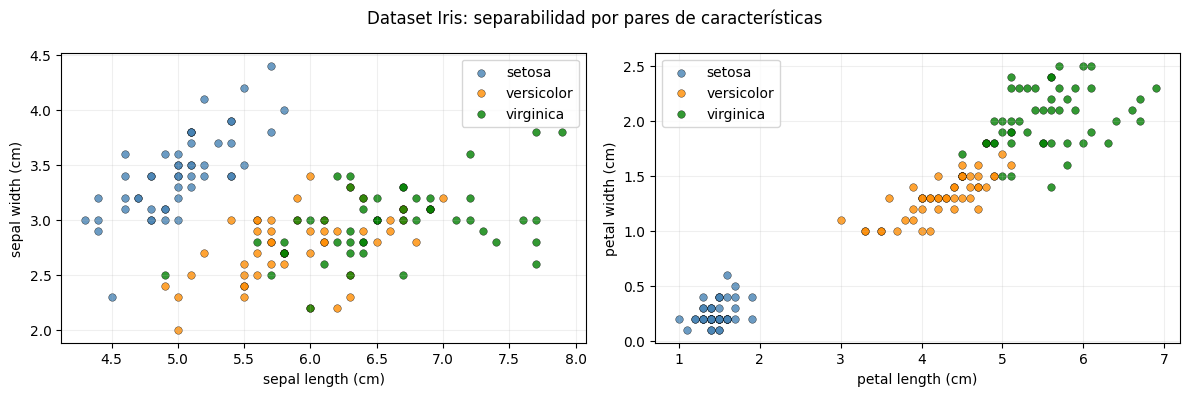

Petal length y petal width separan bien setosa del resto.
Versicolor y virginica se solapan un poco.


In [12]:
# Scatter de dos características para ver separabilidad visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (i, j) in zip(axes, [(0, 1), (2, 3)]):
    for cl, color in zip(range(3), ['steelblue', 'darkorange', 'green']):
        mask = y == cl
        ax.scatter(X[mask, i], X[mask, j], label=nombres_clases[cl],
                   color=color, s=30, alpha=0.8, edgecolor='k', linewidth=0.3)
    ax.set_xlabel(nombres_features[i])
    ax.set_ylabel(nombres_features[j])
    ax.legend()
    ax.grid(alpha=0.2)

plt.suptitle('Dataset Iris: separabilidad por pares de características')
plt.tight_layout()
plt.show()

print('Petal length y petal width separan bien setosa del resto.')
print('Versicolor y virginica se solapan un poco.')

## 3. Entrenamiento del árbol (Punto 4 del enunciado)

Dividimos en 80% train / 20% test y entrenamos `DecisionTreeClassifier`.
El hiperparámetro `max_depth` controla cuánto puede crecer el árbol.

In [13]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

clf = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
clf.fit(X_tr, y_tr)

y_pred = clf.predict(X_te)
acc = accuracy_score(y_te, y_pred)

print(f'Accuracy en test: {acc:.4f}')
print()
print(classification_report(y_te, y_pred, target_names=nombres_clases))

Accuracy en test: 0.9667

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 4. Visualización del árbol de decisión (Punto 5)

Esta es la gran ventaja respecto a redes neuronales: podemos ver exactamente qué regla se aplica en cada nodo.

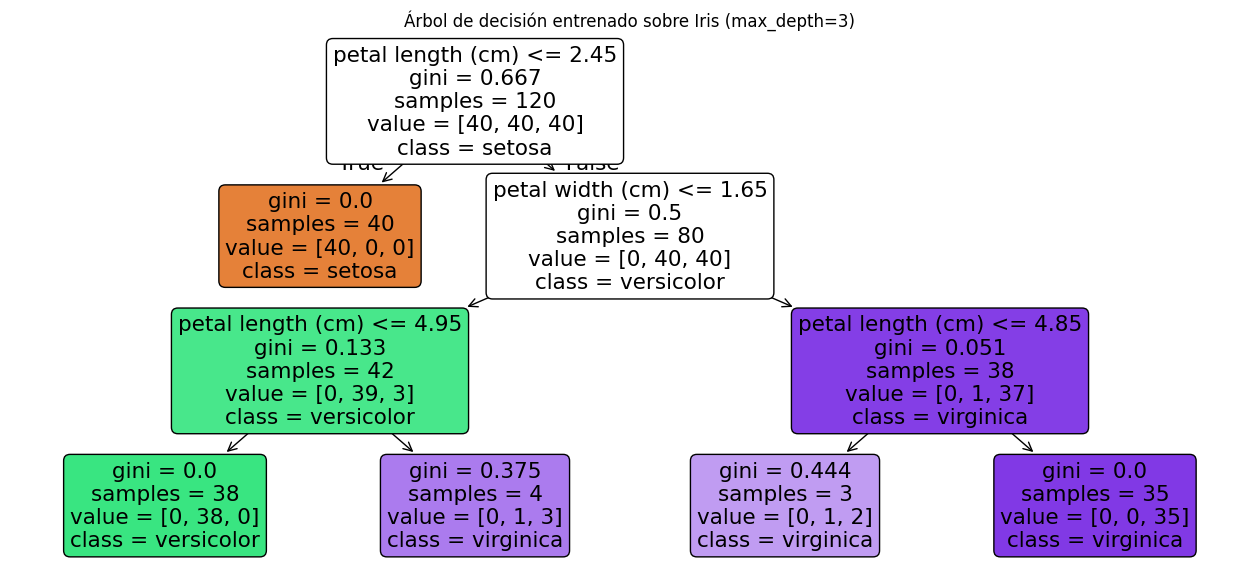

Árbol en formato texto:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



In [14]:
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(
    clf,
    feature_names=nombres_features,
    class_names=nombres_clases,
    impurity=True,
    filled=True,
    rounded=True,
    ax=ax
)
plt.title('Árbol de decisión entrenado sobre Iris (max_depth=3)')
plt.show()

# También en formato texto
print('Árbol en formato texto:')
print(export_text(clf, feature_names=list(nombres_features)))

## 5. Importancia de características (Punto 6)

El árbol asigna una importancia a cada feature según cuánto reduce el Gini en promedio
en todas las particiones donde esa feature fue usada.

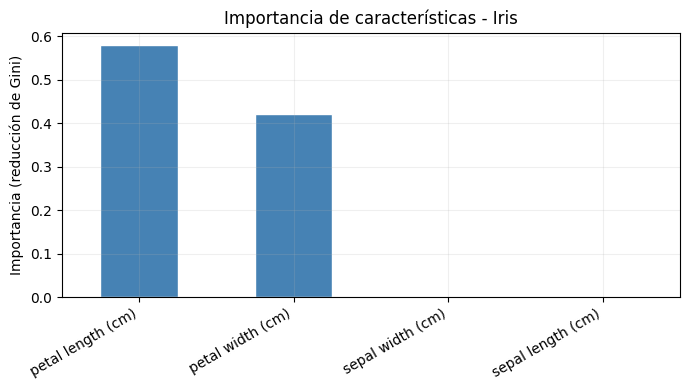

,importancia
petal length (cm),0.5791
petal width (cm),0.4209
sepal width (cm),0.0000
sepal length (cm),0.0000


petal length y petal width concentran prácticamente toda la información discriminante.


In [15]:
importancias = pd.Series(clf.feature_importances_, index=nombres_features).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importancias.plot(kind='bar', color='steelblue', edgecolor='white')
plt.ylabel('Importancia (reducción de Gini)')
plt.title('Importancia de características - Iris')
plt.xticks(rotation=30, ha='right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

display(importancias.to_frame(name='importancia').round(4))
print('petal length y petal width concentran prácticamente toda la información discriminante.')

## 6. Efecto del hiperparámetro max_depth

Un árbol muy profundo puede memorizar el conjunto de entrenamiento (overfitting).
Con validación cruzada encontramos la profundidad óptima.

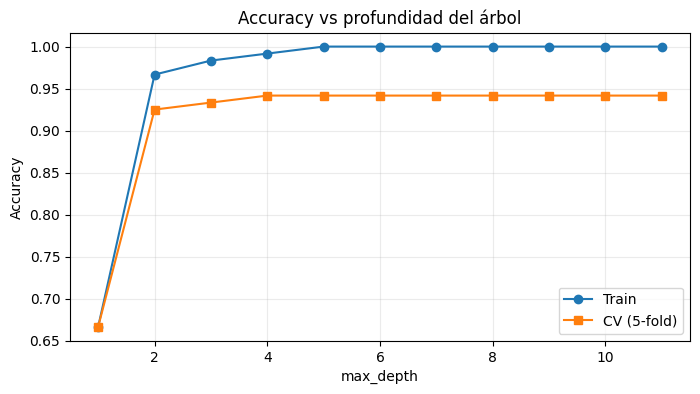

Mejor max_depth según CV: 4
Para profundidades altas, el accuracy en train sube a 1.0 pero el de CV baja: overfitting.


In [16]:
profundidades = range(1, 12)
acc_tr_list, acc_cv_list = [], []

for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth=d, random_state=42)
    arbol.fit(X_tr, y_tr)
    acc_tr_list.append(accuracy_score(y_tr, arbol.predict(X_tr)))
    cv_scores = cross_val_score(arbol, X_tr, y_tr, cv=5, scoring='accuracy')
    acc_cv_list.append(cv_scores.mean())

plt.figure(figsize=(8, 4))
plt.plot(profundidades, acc_tr_list, marker='o', label='Train')
plt.plot(profundidades, acc_cv_list, marker='s', label='CV (5-fold)')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs profundidad del árbol')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

mejor_d = list(profundidades)[acc_cv_list.index(max(acc_cv_list))]
print(f'Mejor max_depth según CV: {mejor_d}')
print('Para profundidades altas, el accuracy en train sube a 1.0 pero el de CV baja: overfitting.')

## 7. Fronteras de decisión para todos los pares de características (Punto 7)

Entrenamos un árbol por cada par de features y visualizamos la región que asigna a cada clase.
Iris tiene 4 features, lo que da $\binom{4}{2} = 6$ pares posibles.

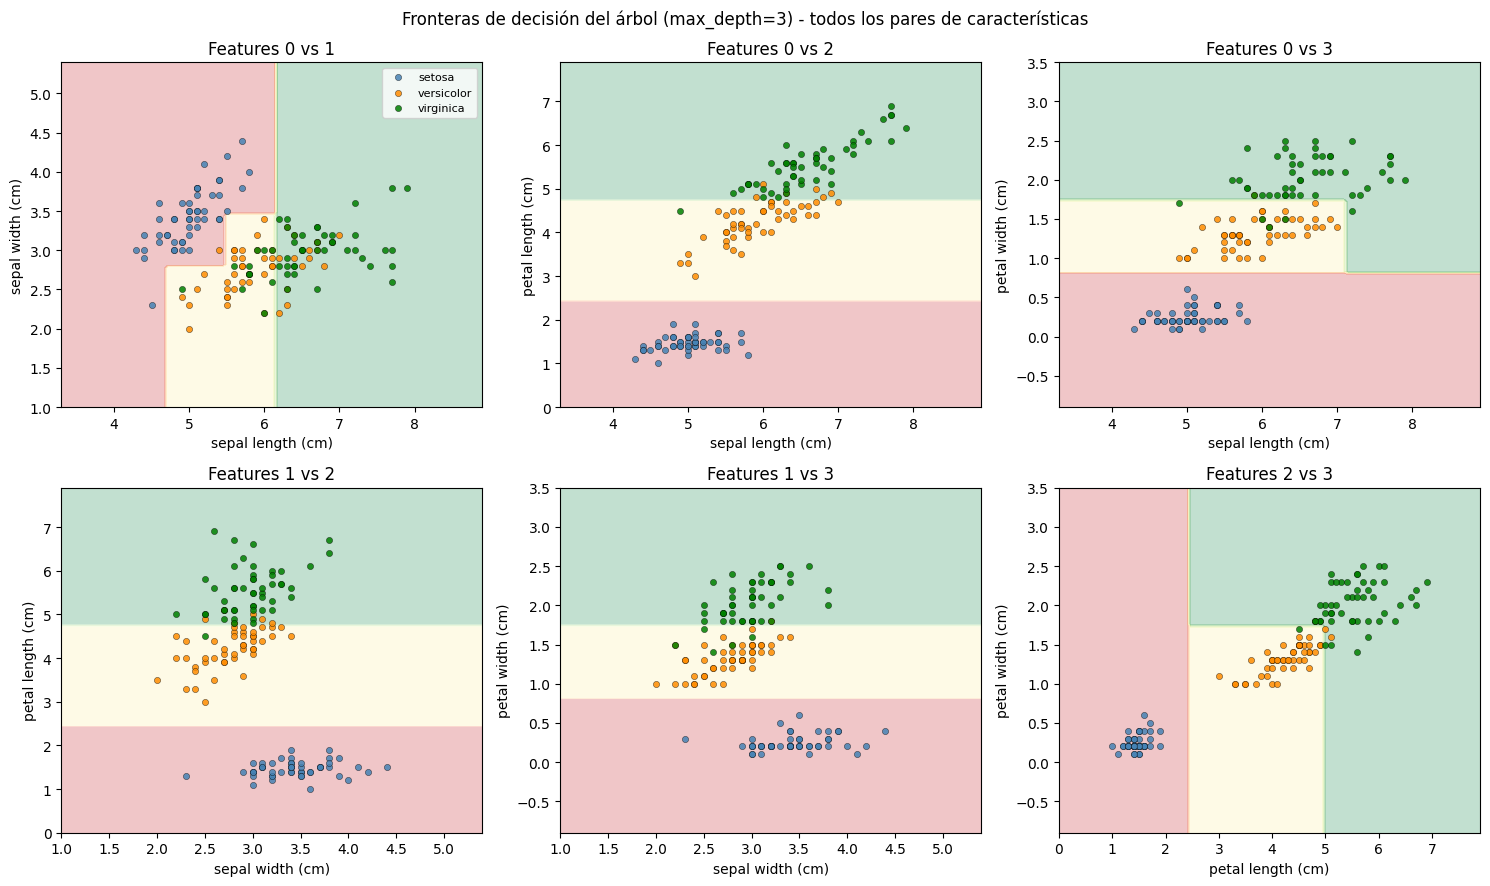

Los pares con petal length/width generan fronteras más limpias.
Los pares de sepal generan más regiones de solapamiento.


In [17]:
pares = list(combinations(range(4), 2))
colores_clases = ['steelblue', 'darkorange', 'green']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for idx, (i, j) in enumerate(pares):
    X_par = X[:, [i, j]]
    clf_par = DecisionTreeClassifier(max_depth=3, random_state=42)
    clf_par.fit(X_par, y)

    DecisionBoundaryDisplay.from_estimator(
        clf_par, X_par,
        response_method='predict',
        alpha=0.25,
        ax=axes[idx],
        cmap='RdYlGn'
    )

    for cl, color in zip(range(3), colores_clases):
        mask = y == cl
        axes[idx].scatter(
            X[mask, i], X[mask, j],
            s=20, color=color, label=nombres_clases[cl],
            edgecolor='k', linewidth=0.3, alpha=0.85
        )

    axes[idx].set_xlabel(nombres_features[i])
    axes[idx].set_ylabel(nombres_features[j])
    axes[idx].set_title(f'Features {i} vs {j}')
    if idx == 0:
        axes[idx].legend(fontsize=8)

plt.suptitle('Fronteras de decisión del árbol (max_depth=3) - todos los pares de características')
plt.tight_layout()
plt.show()

print('Los pares con petal length/width generan fronteras más limpias.')
print('Los pares de sepal generan más regiones de solapamiento.')

## Conclusiones

- Los árboles de decisión son muy interpretables: cada predicción sigue un camino de condiciones visibles.
- En Iris, `petal length` y `petal width` concentran casi toda la información útil.
- `max_depth` es el hiperparámetro más importante: controla directamente el riesgo de overfitting.
- Para profundidades mayores a 3-4 en Iris el árbol empieza a memorizar el train set sin ganar en validación.
- Las fronteras de decisión son siempre rectas paralelas a los ejes (el árbol solo hace cortes ortogonales a las features).